Zadanie 9 -- Segmentacja klientów na Wine
Użyj datasetu Wine (load_wine) do segmentacji win:
Zastosuj (PCA 2D) do wizualizacji
Porównaj k-Means, DBSCAN i Agglomerative
Zmierz Silhouette Score i Calinski-Harabasz Index
Zinterpretuj segmenty (jakie cechy je rozróżniają?)
Oczekiwany wynik: porównanie 3 algorytmów z interpretacją

Rozmiar danych: (178, 13) (178 próbek, 13 cech)
Wyjaśniona wariancja przez PCA: 55.41%

Dobór eps (percentyl 50 k-distance, k=5): 2.22 (p70=2.48 byłby za duży)

=== Ewaluacja metryk (DBSCAN: bez punktów szumu) ===
k-Means         | Klastry: 3 | Szum: 0 | Silhouette: 0.2849 | Calinski-Harabasz: 70.9
Agglomerative   | Klastry: 3 | Szum: 0 | Silhouette: 0.2774 | Calinski-Harabasz: 67.6
DBSCAN          | Klastry: 2 | Szum: 49 | Silhouette: 0.3418 | Calinski-Harabasz: 71.3

Tabela porównawcza:
     algorytm  klastry  szum  silhouette  calinski_harabasz
      k-Means        3     0      0.2849            70.9400
Agglomerative        3     0      0.2774            67.6475
       DBSCAN        2    49      0.3418            71.2534


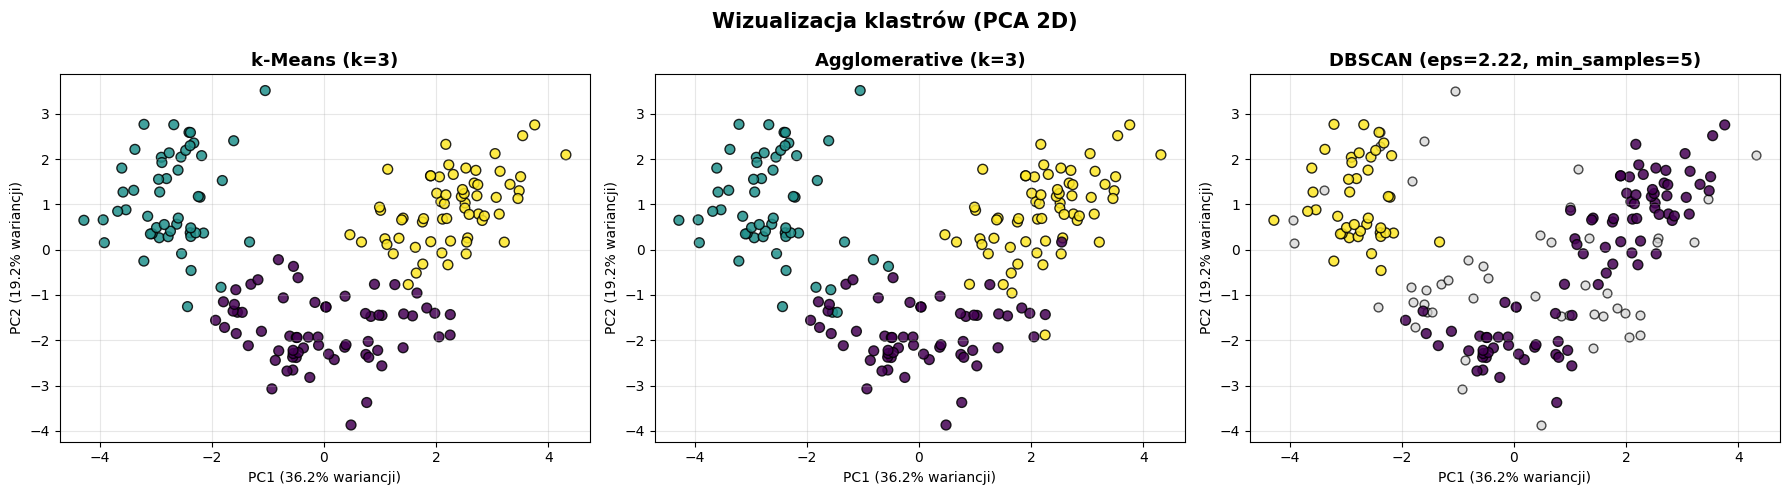


=== Profil cech (średnie w klastrach k-Means) ===
         alcohol  malic_acid  flavanoids  color_intensity  total_phenols   n
Segment                                                                     
0          12.25        1.90        2.05             2.97           2.25  65
1          13.13        3.31        0.82             7.23           1.68  51
2          13.68        2.00        3.00             5.45           2.85  62

=== Interpretacja segmentów (k-Means) ===
Segment 0 (n=65): najniższy alkohol, najjaśniejszy kolor.
Segment 1 (n=51): najwięcej kwasu jabłkowego, najmniej flawonoidów, najintensywniejszy kolor.
Segment 2 (n=62): najwyższy alkohol, najwięcej flawonoidów.

=== Porównanie algorytmów ===
Ranking Silhouette (wyższe = lepsze rozdzielenie):
  DBSCAN: sil=0.3418, CH=71.3, klastry=2, szum=49
  k-Means: sil=0.2849, CH=70.9, klastry=3, szum=0
  Agglomerative: sil=0.2774, CH=67.6, klastry=3, szum=0
Wniosek: k-Means i Agglomerative dają podobne 3 segmenty (zgodnie z 3 o

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

# Wyciszenie standardowych ostrzeżeń z biblioteki sklearn i Pythona
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Wyciszenie błędów matematycznych (overflow, divide by zero) bezpośrednio w silniku NumPy
np.seterr(all='ignore')

# 1. Wczytanie danych
wine = load_wine()
X = wine.data
feature_names = wine.feature_names

print(f"Rozmiar danych: {X.shape} (178 próbek, 13 cech)")

# Standaryzacja -- wymagana dla k-Means, DBSCAN i Agglomerative (odległości)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. PCA tylko do wizualizacji 2D (klasteryzacja na pełnych 13 cechach)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"Wyjaśniona wariancja przez PCA: {pca.explained_variance_ratio_.sum():.2%}\n")

# 3. Trzy algorytmy klasteryzacji
# Wine ma 3 odmiany -- bierzemy k=3 (jak w przykładach z lekcji dla Iris)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

agg = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_agg = agg.fit_predict(X_scaled)

# Dobór eps z k-distance (5. sąsiad = min_samples)
# Na Wine eps~2.5 zlewa wszystko do 1 klastra -- bierzemy ok. "łokcia" k-distance
k_nn = 5
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X_scaled)
dists, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(dists[:, -1])
eps = float(np.percentile(k_dist, 50))  # ~2.2; percentyl 70 (~2.5) -> 1 klaster
print(
    f"Dobór eps (percentyl 50 k-distance, k={k_nn}): {eps:.2f} "
    f"(p70={np.percentile(k_dist, 70):.2f} byłby za duży)"
)

dbscan = DBSCAN(eps=eps, min_samples=k_nn)
labels_dbscan = dbscan.fit_predict(X_scaled)

# 4. Metryki -- dla DBSCAN liczymy bez szumu (-1)
def evaluate(name, labels, X_data):
    n_noise = int((labels == -1).sum())
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    mask = labels != -1
    n_core = int(mask.sum())

    if n_clusters < 2 or n_core < 2:
        print(
            f"{name:15s} | Klastry: {n_clusters} | Szum: {n_noise} | "
            "Zbyt mało klastrów do metryk"
        )
        return {
            "algorytm": name,
            "klastry": n_clusters,
            "szum": n_noise,
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
        }

    sil = silhouette_score(X_data[mask], labels[mask])
    ch = calinski_harabasz_score(X_data[mask], labels[mask])
    print(
        f"{name:15s} | Klastry: {n_clusters} | Szum: {n_noise} | "
        f"Silhouette: {sil:.4f} | Calinski-Harabasz: {ch:.1f}"
    )
    return {
        "algorytm": name,
        "klastry": n_clusters,
        "szum": n_noise,
        "silhouette": sil,
        "calinski_harabasz": ch,
    }

print("\n=== Ewaluacja metryk (DBSCAN: bez punktów szumu) ===")
results = [
    evaluate("k-Means", labels_kmeans, X_scaled),
    evaluate("Agglomerative", labels_agg, X_scaled),
    evaluate("DBSCAN", labels_dbscan, X_scaled),
]
comparison = pd.DataFrame(results)
print("\nTabela porównawcza:")
print(comparison.round(4).to_string(index=False))

# 5. Wizualizacja PCA
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_clusters(ax, labels, title):
    # Szum DBSCAN (-1) rysujemy osobno na szaro
    core = labels != -1
    if (~core).any():
        ax.scatter(
            X_pca[~core, 0],
            X_pca[~core, 1],
            c="lightgray",
            alpha=0.7,
            edgecolor="k",
            s=40,
            label="szum",
        )
    ax.scatter(
        X_pca[core, 0],
        X_pca[core, 1],
        c=labels[core],
        cmap="viridis",
        alpha=0.85,
        edgecolor="k",
        s=50,
    )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} wariancji)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} wariancji)")
    ax.grid(True, alpha=0.3)

plot_clusters(axes[0], labels_kmeans, "k-Means (k=3)")
plot_clusters(axes[1], labels_agg, "Agglomerative (k=3)")
plot_clusters(axes[2], labels_dbscan, f"DBSCAN (eps={eps:.2f}, min_samples={k_nn})")

plt.suptitle("Wizualizacja klastrów (PCA 2D)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# 6. Interpretacja segmentów (profil cech k-Means)
df = pd.DataFrame(X, columns=feature_names)
df["Segment"] = labels_kmeans
key_features = [
    "alcohol",
    "malic_acid",
    "flavanoids",
    "color_intensity",
    "total_phenols",
]

print("\n=== Profil cech (średnie w klastrach k-Means) ===")
profile = df.groupby("Segment")[key_features].mean().round(2)
profile["n"] = df.groupby("Segment").size()
print(profile)

# Opisy budujemy z profilu, żeby numery segmentów zawsze się zgadzały
rows = profile.sort_index()
print("\n=== Interpretacja segmentów (k-Means) ===")
for seg, row in rows.iterrows():
    traits = []
    if row["alcohol"] == rows["alcohol"].max():
        traits.append("najwyższy alkohol")
    if row["alcohol"] == rows["alcohol"].min():
        traits.append("najniższy alkohol")
    if row["malic_acid"] == rows["malic_acid"].max():
        traits.append("najwięcej kwasu jabłkowego")
    if row["flavanoids"] == rows["flavanoids"].max():
        traits.append("najwięcej flawonoidów")
    if row["flavanoids"] == rows["flavanoids"].min():
        traits.append("najmniej flawonoidów")
    if row["color_intensity"] == rows["color_intensity"].max():
        traits.append("najintensywniejszy kolor")
    if row["color_intensity"] == rows["color_intensity"].min():
        traits.append("najjaśniejszy kolor")
    print(f"Segment {seg} (n={int(row['n'])}): {', '.join(traits)}.")

print("\n=== Porównanie algorytmów ===")
ranked = comparison.dropna(subset=["silhouette"]).sort_values(
    "silhouette", ascending=False
)
print("Ranking Silhouette (wyższe = lepsze rozdzielenie):")
for _, row in ranked.iterrows():
    print(
        f"  {row['algorytm']}: sil={row['silhouette']:.4f}, "
        f"CH={row['calinski_harabasz']:.1f}, "
        f"klastry={int(row['klastry'])}, szum={int(row['szum'])}"
    )
print(
    "Wniosek: k-Means i Agglomerative dają podobne 3 segmenty (zgodnie z "
    "3 odmianami Wine) i pełne pokrycie danych. DBSCAN może mieć wyższy "
    "Silhouette, bo odrzuca punkty brzegowe jako szum i często znajduje "
    "mniej grup -- metryka jest wtedy liczona na 'łatwiejszym' podzbiorze. "
    "Do segmentacji klientów/win z oczekiwanymi 3 grupami lepiej nadają "
    "się k-Means / Agglomerative; DBSCAN pokazuje gęstość i outliers."
)
